Telco Customer Churn — Experimentación




In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

from preprocessing import load_raw_data, clean_data, encode_features, split_data

## 1. Dataset Loading and Exploration


In [2]:
df = load_raw_data("../datasets/telco_churn.csv")
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#tarjet distribution

df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

The dataset is moderately imbalanced (~26.5% of customers churn). Therefore, we evaluate the model using multiple metrics (not just accuracy), especially precision, recall, and F1-score.

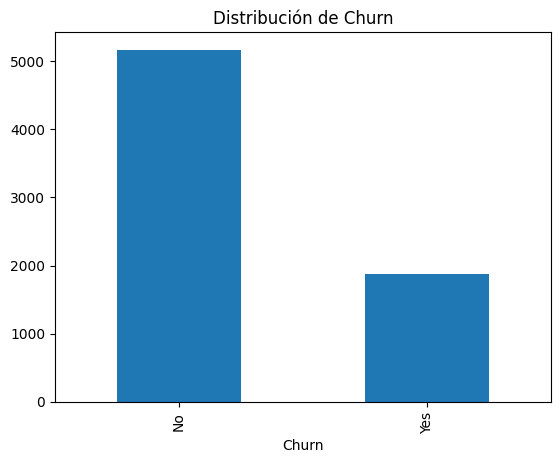

In [5]:
df["Churn"].value_counts().plot(kind="bar", title="Distribución de Churn")
plt.show()

## 2. Data cleaning

In [6]:
df_clean = clean_data(df)
df_clean.isna().sum().sum()  # debe ser 0

np.int64(0)

Preprocessing Decision: TotalCharges was originally stored as text, with blank values for the 11 customers whose tenure = 0 (newly acquired customers). It was converted to a numeric variable and the missing values were imputed with 0, as this correctly reflects that these customers have not yet been billed.

** 3. Encoding and Train-Test Split**


In [7]:
X, y, feature_columns = encode_features(df_clean)
X_train, X_test, y_train, y_test = split_data(X, y)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("N features:", len(feature_columns))

Train: (5634, 30) Test: (1409, 30)
N features: 30


4. Training and MLflow Tracking
The actual training (with MLflow logging) is executed by calling src/train.py, which is the same script that runs the CD pipeline. This ensures that the model evaluated here is identical to the one that is deployed.

In [8]:
!cd .. && python3 src/train.py

2026/06/24 11:44:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[logistic_regression] {'accuracy': 0.8069552874378992, 'precision': 0.6583850931677019, 'recall': 0.5668449197860963, 'f1_score': 0.6091954022988506, 'roc_auc': 0.841778397788628}


2026/06/24 11:44:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[random_forest] {'accuracy': 0.7998580553584103, 'precision': 0.6654676258992805, 'recall': 0.4946524064171123, 'f1_score': 0.5674846625766872, 'roc_auc': 0.8441977317936398}

Mejor modelo: logistic_regression (f1=0.6092)
Modelo guardado en: models/model.pkl


5. Experiment Results

Capturas de pantalla de la UI de MLflow (`mlflow ui --backend-store-uri sqlite:///mlflow.db`)
mostrando los runs de `logistic_regression` y `random_forest` con sus métricas:

<div style="display: flex; gap: 10px;">
  <img src="../utils/Screenshot2.png" width="48%">
  <img src="../utils/Screenshot.png" width="55%">
</div>

6. Final Model Selection
Two intentionally simple models were evaluated (logistic regression and random forest), avoiding overly complicated architectures as requested by the project brief.

In [9]:
results = pd.read_csv("../models/training_results.csv")
results

,model,accuracy,precision,recall,f1_score,roc_auc
0,logistic_regression,0.806955,0.658385,0.566845,0.609195,0.841778
1,random_forest,0.799858,0.665468,0.494652,0.567485,0.844198


Selected Model: Logistic Regression

Justification:

Better F1-score and better balance between precision and recall than Random Forest.

Simple and interpretable model: in a business case like customer retention, being able to explain why a customer is at risk of churn (via the coefficients) is as valuable as the prediction itself.

Lower risk of overfitting given the moderate dataset size (~7000 rows).

7. On-demand Workflow (Quick Validation)

In [10]:
!cd .. && python3 src/predict.py

Predicciones guardadas en: batch_prediction_dataset/predictions.csv


   customerID churn_prediction  churn_probability
0  9259-PACGQ               No             0.1111
1  5914-DVBWJ              Yes             0.5460
2  9734-YWGEX              Yes             0.6449
3  5035-PGZXH               No             0.3005
4  6362-QHAFM               No             0.3458


In [11]:
preds = pd.read_csv("../batch_prediction_dataset/predictions.csv")
preds

,customerID,churn_prediction,churn_probability
0,9259-PACGQ,No,0.1111
1,5914-DVBWJ,Yes,0.5460
2,9734-YWGEX,Yes,0.6449
3,5035-PGZXH,No,0.3005
4,6362-QHAFM,No,0.3458
5,6207-WIOLX,No,0.2603
6,9369-XFEHK,No,0.4247
7,3420-YJLQT,Yes,0.6391
8,4801-KFYKL,No,0.1154
9,6212-ATMLK,Yes,0.5363
